<a href="https://colab.research.google.com/github/Revanthkovvuri/tourist_safety_predictor/blob/main/tourist_safety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/go_track_trackspoints.csv")

In [ ]:
# Check for and sum up all the null (missing) values in each column
print(df.isnull().sum())

id           0
latitude     0
longitude    0
track_id     0
time         0
dtype: int64


In [ ]:
df['time']=pd.to_datetime(df['time'])
df=df.sort_values(by=['track_id','time'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 18107 entries, 0 to 18106
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         18107 non-null  int64         
 1   latitude   18107 non-null  float64       
 2   longitude  18107 non-null  float64       
 3   track_id   18107 non-null  int64         
 4   time       18107 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 848.8 KB
None


In [ ]:

df['timeelapsed'] = df.groupby("track_id")['time'].diff().dt.total_seconds()


print(df.head())

   id   latitude  longitude  track_id                time  timeelapsed
0   1 -10.939341 -37.062742         1 2014-09-13 07:24:32          NaN
1   2 -10.939341 -37.062742         1 2014-09-13 07:24:37          5.0
2   3 -10.939324 -37.062765         1 2014-09-13 07:24:42          5.0
3   4 -10.939211 -37.062843         1 2014-09-13 07:24:47          5.0
4   5 -10.938939 -37.062879         1 2014-09-13 07:24:53          6.0


In [ ]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000  # Radius of Earth in meters

    phi_1 = np.radians(lat1)
    phi_2 = np.radians(lat2)

    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2.0) ** 2 + np.cos(phi_1) * np.cos(phi_2) * np.sin(delta_lambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    meters = R * c
    return meters

# Create new columns for the previous latitude and longitude
# The .shift(1) function gets the value from the previous row
df['prev_lat'] = df.groupby('track_id')['latitude'].shift(1)
df['prev_lon'] = df.groupby('track_id')['longitude'].shift(1)

# Apply the haversine function to calculate the distance
# We drop the temporary 'prev' columns after the calculation is done
df['distance_meters'] = haversine_distance(df['prev_lat'], df['prev_lon'], df['latitude'], df['longitude'])
df = df.drop(columns=['prev_lat', 'prev_lon'])


print(df.head())

   id   latitude  longitude  track_id                time  timeelapsed  \
0   1 -10.939341 -37.062742         1 2014-09-13 07:24:32          NaN   
1   2 -10.939341 -37.062742         1 2014-09-13 07:24:37          5.0   
2   3 -10.939324 -37.062765         1 2014-09-13 07:24:42          5.0   
3   4 -10.939211 -37.062843         1 2014-09-13 07:24:47          5.0   
4   5 -10.938939 -37.062879         1 2014-09-13 07:24:53          6.0   

   distance_meters  
0              NaN  
1         0.000007  
2         3.121273  
3        15.246923  
4        30.447037  


In [ ]:
df['speedms']=df['distance_meters']/df['timeelapsed']
print(df.head())
print("staticstics of the speed column")
print(df['speedms'].describe())

   id   latitude  longitude  track_id                time  timeelapsed  \
0   1 -10.939341 -37.062742         1 2014-09-13 07:24:32          NaN   
1   2 -10.939341 -37.062742         1 2014-09-13 07:24:37          5.0   
2   3 -10.939324 -37.062765         1 2014-09-13 07:24:42          5.0   
3   4 -10.939211 -37.062843         1 2014-09-13 07:24:47          5.0   
4   5 -10.938939 -37.062879         1 2014-09-13 07:24:53          6.0   

   distance_meters   speedms  
0              NaN       NaN  
1         0.000007  0.000001  
2         3.121273  0.624255  
3        15.246923  3.049385  
4        30.447037  5.074506  
staticstics of the speed column
count    17942.000000
mean         6.289627
std          7.301773
min          0.000000
25%          0.237185
50%          4.178871
75%         10.731733
max        315.207950
Name: speedms, dtype: float64


In [ ]:
import numpy as np

def calculate_bearing(lat1, lon1, lat2, lon2):
    # Convert latitudes and longitudes to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Calculate the change in longitudes
    dLon = lon2 - lon1

    # Calculate the bearing
    x = np.sin(dLon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dLon)

    initial_bearing = np.arctan2(x, y)

    # Convert bearing from radians to degrees
    initial_bearing = np.degrees(initial_bearing)

    # Normalize the bearing to be within 0-360 degrees
    bearing = (initial_bearing + 360) % 360

    return bearing

# Create temporary columns for the previous latitude and longitude again
df['prev_lat'] = df.groupby('track_id')['latitude'].shift(1)
df['prev_lon'] = df.groupby('track_id')['longitude'].shift(1)

# Apply the bearing function
df['bearing'] = calculate_bearing(df['prev_lat'], df['prev_lon'], df['latitude'], df['longitude'])

# Drop the temporary columns
df = df.drop(columns=['prev_lat', 'prev_lon'])

# Print the first 5 rows to see the new 'bearing' column
print(df.head())

   id   latitude  longitude  track_id                time  timeelapsed  \
0   1 -10.939341 -37.062742         1 2014-09-13 07:24:32          NaN   
1   2 -10.939341 -37.062742         1 2014-09-13 07:24:37          5.0   
2   3 -10.939324 -37.062765         1 2014-09-13 07:24:42          5.0   
3   4 -10.939211 -37.062843         1 2014-09-13 07:24:47          5.0   
4   5 -10.938939 -37.062879         1 2014-09-13 07:24:53          6.0   

   distance_meters   speedms     bearing  
0              NaN       NaN         NaN  
1         0.000007  0.000001  321.286483  
2         3.121273  0.624255  308.405475  
3        15.246923  3.049385  325.783535  
4        30.447037  5.074506  352.675856  


In [ ]:
# Calculate Acceleration (change in speed over time)
df['acceleration'] = df.groupby('track_id')['speedms'].diff() / df['timeelapsed']

# Extract Time-Based Features
df['hour_of_day'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek # Monday=0, Sunday=6

# --- Now, let's update our final feature set ---

# First, drop any new NaN values created by the acceleration calculation
df = df.dropna()

# Select the new, richer set of feature columns
feature_columns = [
    'latitude',
    'longitude',
    'timeelapsed',
    'distance_meters',
    'speedms',
    'bearing',
    'acceleration', # Our new feature
    'hour_of_day',  # Our new feature
    'day_of_week'   # Our new feature
]
features_df = df[feature_columns]

# Print the first 5 rows of our new final feature set
print("Final features (with acceleration and time) ready for scaling:")
print(features_df.head())

Final features (with acceleration and time) ready for scaling:
    latitude  longitude  timeelapsed  distance_meters   speedms     bearing  \
2 -10.939324 -37.062765          5.0         3.121273  0.624255  308.405475   
3 -10.939211 -37.062843          5.0        15.246923  3.049385  325.783535   
4 -10.938939 -37.062879          6.0        30.447037  5.074506  352.675856   
5 -10.938544 -37.062839          6.0        44.180774  7.363462    5.663374   
6 -10.938346 -37.062588          5.0        35.127855  7.025571   51.297328   

   acceleration  hour_of_day  day_of_week  
2      0.124851            7            5  
3      0.485026            7            5  
4      0.337520            7            5  
5      0.381493            7            5  
6     -0.067578            7            5  


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Fit the scaler to the data and transform it
scaled_features = scaler.fit_transform(features_df)

# Print the first 5 rows of the scaled data to see the result
# The output is now a NumPy array, not a Pandas DataFrame
print("Scaled features (now a NumPy array):")
print(scaled_features[:5])

# Also, let's save the scaler so we can use it later for new data
import joblib
joblib.dump(scaler, 'scaler.gz')

Scaled features (now a NumPy array):
[[9.62654350e-01 9.53169814e-01 2.92611558e-03 3.55779170e-04
  1.98045331e-03 8.56707212e-01 6.22718441e-01 2.38095238e-01
  8.33333333e-01]
 [9.62660900e-01 9.53163345e-01 2.92611558e-03 1.73792471e-03
  9.67419973e-03 9.04981030e-01 6.34031627e-01 2.38095238e-01
  8.33333333e-01]
 [9.62676589e-01 9.53160416e-01 3.65764448e-03 3.47051387e-03
  1.60989158e-02 9.79684130e-01 6.29398440e-01 2.38095238e-01
  8.33333333e-01]
 [9.62699431e-01 9.53163706e-01 3.65764448e-03 5.03595760e-03
  2.33606493e-02 1.57320603e-02 6.30779623e-01 2.38095238e-01
  8.33333333e-01]
 [9.62710842e-01 9.53184392e-01 2.92611558e-03 4.00405815e-03
  2.22886860e-02 1.42496793e-01 6.16674207e-01 2.38095238e-01
  8.33333333e-01]]


['scaler.gz']

In [ ]:
import numpy as np

def create_sequences(data, sequence_length):
    sequences = []
    # Loop through the data to create overlapping windows
    for i in range(len(data) - sequence_length + 1):
        sequence = data[i : i + sequence_length]
        sequences.append(sequence)
    # Convert the list of sequences into a single 3D NumPy array
    return np.array(sequences)

# Define the length of our sequences (how many timesteps the model will look at)
SEQUENCE_LENGTH = 10

# Create the 3D array from your scaled_features
X_train = create_sequences(scaled_features, SEQUENCE_LENGTH)

# Print the shape of the new array to confirm it's correct
# The shape should be (number_of_sequences, 10, number_of_features)
print("Shape of the final training data:", X_train.shape)

Shape of the final training data: (17779, 10, 9)


In [ ]:
#model architecture
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

# Get the shape of our training data
n_features = X_train.shape[2] # This gets the number of features from your 3D array

# --- 1. Define the Encoder ---
# The input layer takes one sequence at a time
inputs = Input(shape=(SEQUENCE_LENGTH, n_features))
# The LSTM layer compresses the sequence into a single summary vector
encoder = LSTM(128, activation='relu')(inputs)

# --- 2. Define the Bridge ---
# This layer repeats the summary vector to match the original sequence length
bridge = RepeatVector(SEQUENCE_LENGTH)(encoder)

# --- 3. Define the Decoder ---
# This LSTM layer tries to rebuild the sequence from the repeated summary
decoder = LSTM(128, activation='relu', return_sequences=True)(bridge)
# This final layer ensures the output for each timestep has the correct number of features
output = TimeDistributed(Dense(n_features))(decoder)

# --- 4. Create the Final Model ---
# This pulls all the pieces together into a single autoencoder model
autoencoder = Model(inputs=inputs, outputs=output)

# --- 5. Compile the Model ---
# This prepares the model for training by defining the optimizer and how to measure error
autoencoder.compile(optimizer='adam', loss='mae')

# Print a summary of the architecture you just built
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 9)          │         1,161 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,401 (794.54 KB)

 Trainable params: 203,401 (794.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training of autoencoder
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - loss: 0.1000 - val_loss: 0.0289
Epoch 2/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - loss: 0.0265 - val_loss: 0.0290
Epoch 3/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0245 - val_loss: 0.0327
Epoch 4/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - loss: 0.0240 - val_loss: 0.0294
Epoch 5/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0218 - val_loss: 0.0229
Epoch 6/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - loss: 0.0208 - val_loss: 0.0253
Epoch 7/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - loss: 0.0205 - val_loss: 0.0225
Epoch 8/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0197 - val_loss: 0.0248
Epoch 9/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 0.0200 - val_loss: 0.0224
Epoch 10/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 0.0199 - val_loss: 0.0215
Epoch 11/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 0.0191 - val_loss: 0.0230
Epoch 12/50
501/501 ━━━━━━━━━━

Model saved to anomaly_model.h5


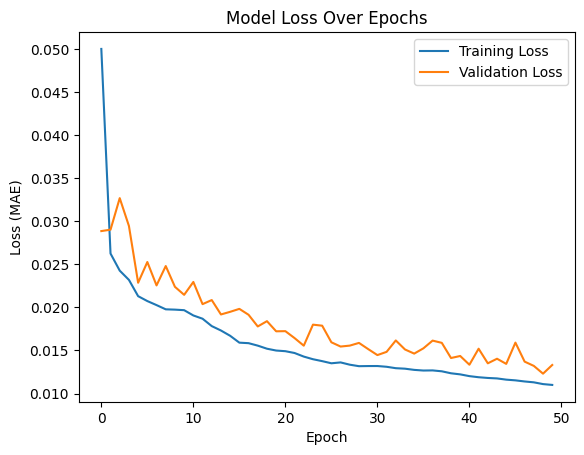

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Save your trained model to a file ---
autoencoder.save('/content/anomaly_model.keras')
print("Model saved to /content/anomaly_model.keras")

# --- 2. Plot the training and validation loss ---
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MAE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
import numpy as np

# 1. Get the model's predictions (reconstructions) on the training data
X_train_pred = autoencoder.predict(X_train)

# 2. Calculate the Mean Absolute Error (MAE) for each sequence
# This gives us a list of reconstruction errors for all the normal data
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

# 3. Set the threshold at 3 standard deviations above the mean error
threshold = np.mean(train_mae_loss) + (2 * np.std(train_mae_loss))

print(f"Reconstruction error threshold: {threshold}")

556/556 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step
Reconstruction error threshold: 0.028935467773301186


In [ ]:
import numpy as np
import joblib
from tensorflow.keras.models import load_model

try:
    # --- 1. Load your saved model WITHOUT compiling it ---
    # We add compile=False to handle the error.
    autoencoder = load_model('/content/anomaly_model.keras', compile=False)

    # --- 2. Now, compile the model manually ---
    autoencoder.compile(optimizer='adam', loss='mae')
    print("Model loaded and re-compiled successfully.")

    # --- 3. Load your scaler ---
    scaler = joblib.load('scaler.gz')

    # --- 4. Define constants from your previous steps ---
    THRESHOLD = threshold
    SEQUENCE_LENGTH = X_train.shape[1]
    N_FEATURES = X_train.shape[2]

    # --- 5. Create a fake anomaly ---
    normal_sequence = X_train[0]
    anomalous_sequence = normal_sequence.copy()
    anomalous_sequence[-1, 3] = anomalous_sequence[-1, 3] * 20
    anomalous_sequence[-1, 4] = anomalous_sequence[-1, 4] * 20
    print("Created a sample anomalous sequence.")

    # --- 6. Reshape data for the model ---
    normal_sequence_reshaped = normal_sequence.reshape(1, SEQUENCE_LENGTH, N_FEATURES)
    anomalous_sequence_reshaped = anomalous_sequence.reshape(1, SEQUENCE_LENGTH, N_FEATURES)

    # --- 7. Get predictions from the model ---
    normal_pred = autoencoder.predict(normal_sequence_reshaped)
    anomalous_pred = autoencoder.predict(anomalous_sequence_reshaped)

    # --- 8. Calculate error and check against the threshold ---
    normal_loss = np.mean(np.abs(normal_pred - normal_sequence_reshaped))
    anomalous_loss = np.mean(np.abs(anomalous_pred - anomalous_sequence_reshaped))

    print("-" * 40)
    print(f"Normal Sequence Reconstruction Error:   {normal_loss:.6f}")
    print(f"Anomalous Sequence Reconstruction Error: {anomalous_loss:.6f}")
    print(f"Your Anomaly Threshold is:              {THRESHOLD:.6f}")
    print("-" * 40)

    if anomalous_loss > THRESHOLD:
        print("\nSUCCESS: The model correctly identified the anomaly!")
    else:
        print("\nFAILURE: The model did not identify the anomaly.")

except NameError as e:
    print(f"\nERROR: A NameError occurred -> {e}")
    print("This means a variable was not defined. Please go to the 'Runtime' menu and click 'Run all' to execute your notebook from the beginning.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

An unexpected error occurred: [Errno 2] Unable to synchronously open file (unable to open file: name = 'anomaly_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
